## What are Embeddings ??

Think of Embeddings as a way to translate words into a language thatcomputer understand - Numbers!

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
##Simplified 2D example (real embeddings have hundreds of Dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45,0.15]
}

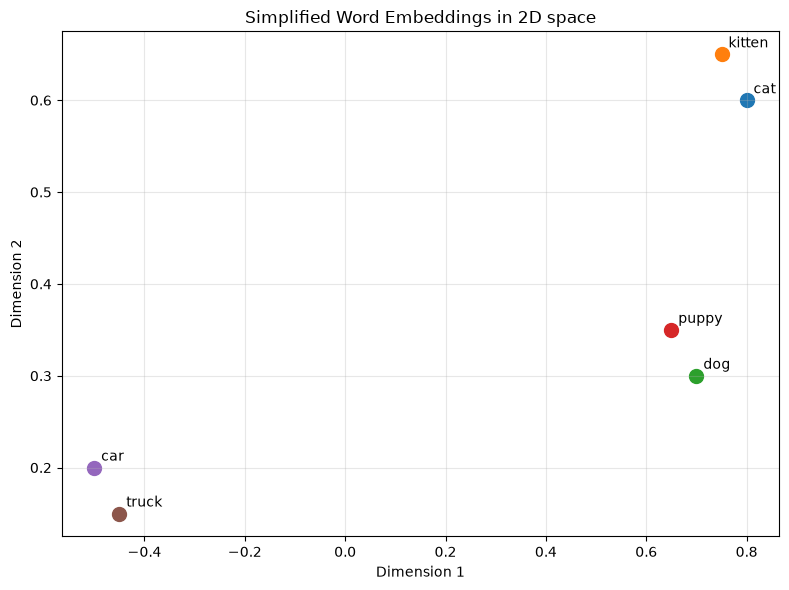

In [7]:
## Plotting the vectoirs on a graph
fig,ax = plt.subplots(figsize=(8,6))
for word,coords in word_embeddings.items():
    ax.scatter(coords[0],coords[1],s=100)
    ax.annotate(word,(coords[0],coords[1]),xytext = (5,5),textcoords="offset points")

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Simplified Word Embeddings in 2D space")
ax.grid(True,alpha = 0.3)

plt.tight_layout()
plt.show()

## Measuring the Similarity

In [8]:
def cosine_similarity(vec1,vec2):
    """
    Cosine Similarity measures the angle between the two vectors
    - Result close to 1: Very Similar
    - Result close to 0: not Related
    - Result close to -1: Oppposite Message
    """
    dot_product = np.dot(vec1,vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product/((norm_a)*(norm_b))

In [11]:
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75,0.65,0.35]
car_vector = [-0.5,0.2,0.1]

cat_kitten_similarity = cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [12]:
car_cat_similarity = cosine_similarity(car_vector,cat_vector)
print(car_cat_similarity)

-0.43718588548916804


## Creating your first embeddings

In [1]:
## Hugging Face and OpenAI models
from langchain_huggingface import HuggingFaceEmbeddings

## initialize a simple embedding model (no API Key Needed)
embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)
embeddings

f:\D Drive\Udemy_RAG (Krish Naik)\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hp\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9666.89it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [3]:
## Create your first embeddings
text = "Hello!, I am learning about embeddings"
embedding = embeddings.embed_query(text=text)
print(f"Text: {text}")
print(f"Embedding Length: {len(embedding)}")
print(f"Embeddings: {embedding}")


Text: Hello!, I am learning about embeddings
Embedding Length: 384
Embeddings: [-0.015691056847572327, -0.1007850244641304, 0.012406972236931324, -0.0023477908689528704, 0.016754331067204475, 0.05693948268890381, -0.0011524728033691645, 0.009510407224297523, 0.025889413431286812, -0.023265808820724487, 0.022633716464042664, 0.06911735236644745, 0.05338418856263161, 0.013500000350177288, -0.055723756551742554, 0.02297229878604412, 0.03478580713272095, 0.08718995004892349, -0.07626748830080032, 0.01356826163828373, -0.03141741827130318, -0.052733708173036575, 0.019746137782931328, -0.08755605667829514, 0.030250184237957, -0.020546531304717064, -0.03496304526925087, 0.05741903558373451, 0.09490959346294403, -0.0840185210108757, 0.036610160022974014, -0.010412505827844143, -0.026700040325522423, 0.07395147532224655, -0.05213387683033943, 0.11081966757774353, 0.03328728675842285, -0.00701193418353796, -0.06972946226596832, -0.002307651797309518, 0.019784187898039818, 0.04366676136851311, -0

In [8]:
sentences = [
    "The cat is sitting on the mat.",
    "I enjoy learning new programming concepts.",
    "The weather is pleasant today.",
    "She went to the library to study.",
    "Machine learning is an interesting field."
]
embedding = embeddings.embed_documents(sentences)
print(f"Text: {sentences}")
print(f"Embedding Length: {len(embedding[0])}")
print(f"Embeddings: {embedding}")

Text: ['The cat is sitting on the mat.', 'I enjoy learning new programming concepts.', 'The weather is pleasant today.', 'She went to the library to study.', 'Machine learning is an interesting field.']
Embedding Length: 384
Embeddings: [[0.12733937799930573, -0.04188323765993118, -0.030268287286162376, 0.036560047417879105, -0.04217812418937683, 0.04882999137043953, 0.02288779616355896, 0.046894174069166183, -0.0007214400684460998, 0.03195826709270477, -0.03519286960363388, 0.0819956436753273, 0.04080328345298767, 0.01789848692715168, -0.029001755639910698, -0.05169753357768059, -0.061737820506095886, -0.005999490153044462, 0.08236858993768692, 0.03945250064134598, -0.008589348755776882, -0.0002034670178545639, 0.03056669980287552, -0.06645883619785309, -0.04155270755290985, 0.07003498822450638, -0.03696458786725998, -0.035599641501903534, 0.0276882853358984, -0.016635870561003685, -0.06764541566371918, -0.003206105437129736, 0.00936486478894949, 0.04521459341049194, 0.016862509772181

In [9]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },

    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },

    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },

    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },

    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

In [10]:
print("📊 Popular Open Source Embedding Models:\n")

for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📐 Embedding size: {info['size']} dimensions")
    print(f"  📄 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")

📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📐 Embedding size: 384 dimensions
  📄 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📐 Embedding size: 768 dimensions
  📄 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📐 Embedding size: 384 dimensions
  📄 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📐 Embedding size: 384 dimensions
  📄 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📐 Embedding size: 384 dimensions
  📄 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

